# **Shivprasad A. Mahind (123B1B266)**


# **The Decision Tree Classifier**
A Decision Tree is a supervised machine learning algorithm that's popular for its intuitive and interpretable structure. It works like a flowchart, making it easy to understand how it arrives at a decision. 🌳

The tree is composed of several key parts:

*   Root Node: The top-most node, representing the entire dataset.
*   Internal Nodes: These nodes represent a test or a question about a specific feature (e.g., "Is the contract Month-to-month?").
*   Branches: Each branch extending from a node represents an outcome or answer to the test (e.g., 'Yes' or 'No').
*   Leaf Nodes: These are the terminal nodes at the bottom of the tree that represent the final decision or class label (e.g., 'Churn' or 'No Churn').

The goal of the algorithm is to create a model that predicts a target variable by learning simple decision rules from the data features. You can trace a path from the root to a leaf to see exactly which rules led to a specific prediction.

Original Data Head:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies 

/tmp/ipython-input-1500301556.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


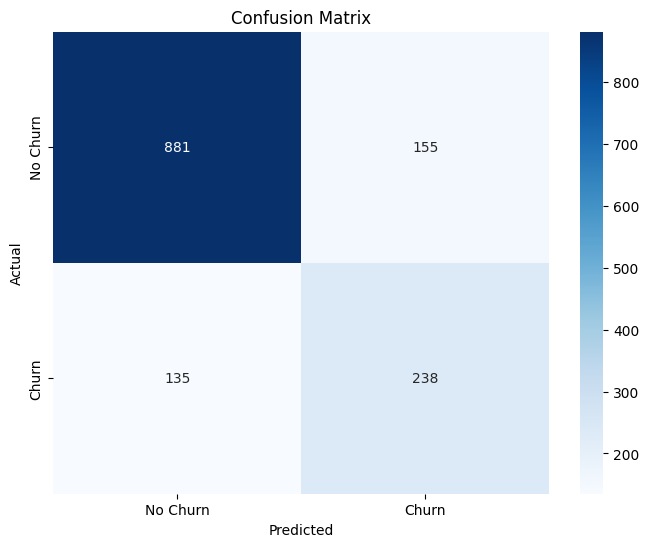

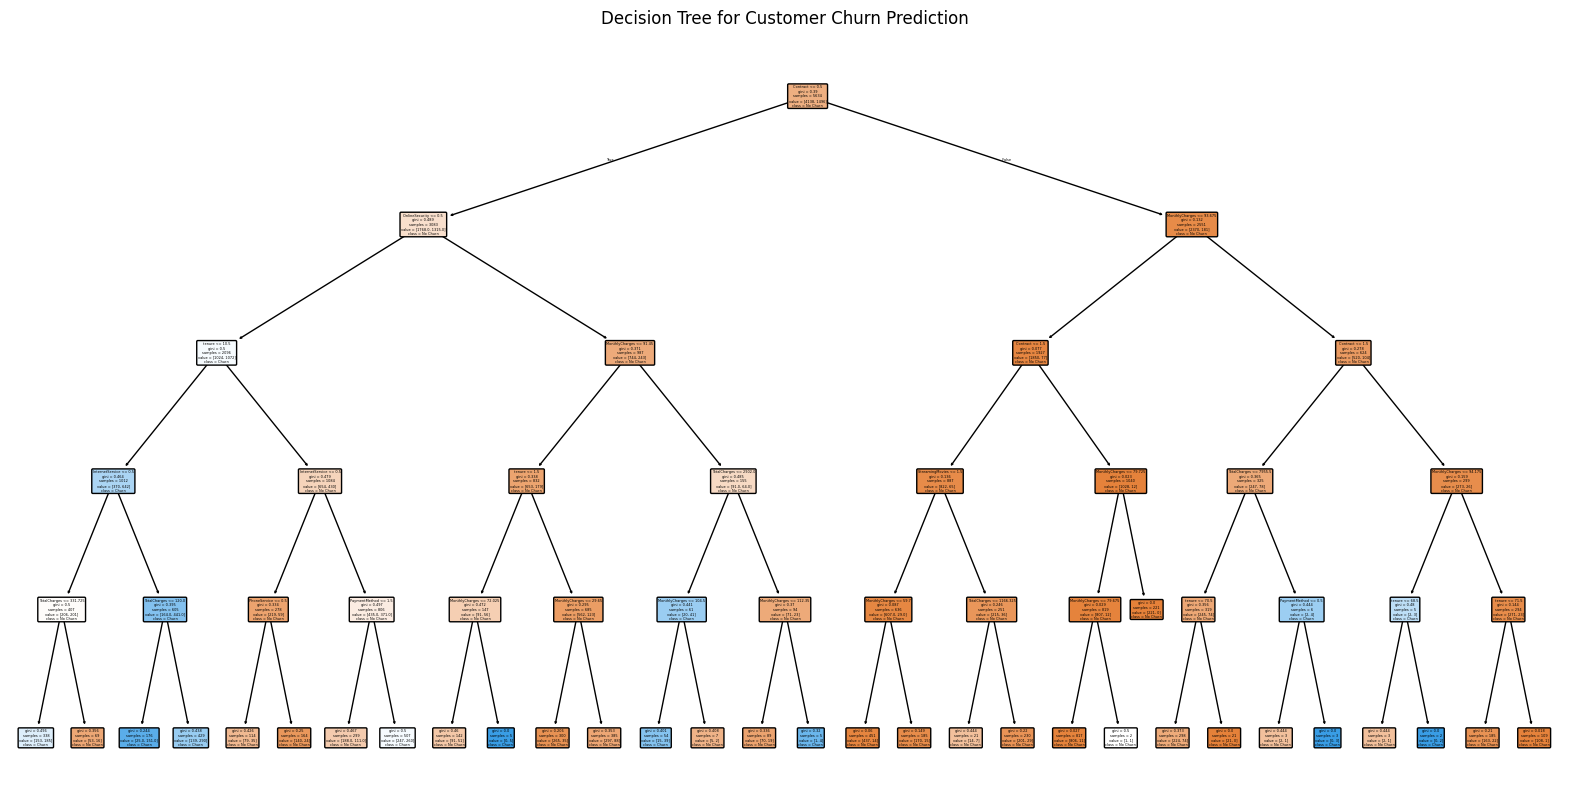

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Make sure to have the 'WA_Fn-UseC_-Telco-Customer-Churn.csv' file in the same directory
# or provide the correct path.
try:
    df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
except FileNotFoundError:
    print("Dataset file not found. Please download it from:")
    print("https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
    exit()

# --- 1. Data Preprocessing ---

# Display the first few rows and info to understand the data
print("Original Data Head:")
print(df.head())
print("\nData Info:")
df.info()

# The 'TotalCharges' column is object type but should be numeric.
# Let's convert it, coercing errors to NaN (Not a Number) for rows with empty strings.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the customerID column as it's not a useful feature for prediction.
df = df.drop('customerID', axis=1)

# Handle missing values.
# We'll fill the missing 'TotalCharges' with the median of the column.
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode categorical variables into numerical format.
# We'll use LabelEncoder for this task.
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nPreprocessed Data Head:")
print(df.head())

# --- 2. Splitting the Data ---

# Define features (X) and the target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- 3. Building and Training the Decision Tree Classifier ---

# Initialize the Decision Tree Classifier
# We can set max_depth to prevent the tree from becoming too complex and overfitting.
clf = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the classifier on the training data
clf.fit(X_train, y_train)

print("\nDecision Tree Classifier trained successfully!")

# --- 4. Evaluating the Model ---

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- 5. Visualizing the Decision Tree (Optional) ---
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True, rounded=True)
plt.title("Decision Tree for Customer Churn Prediction")
plt.show()

# **How a Decision Tree Learns**
The tree is built through a process called recursive partitioning. It starts with the whole dataset at the root node and iteratively splits the data into smaller, more homogeneous (or "purer") subsets.

At each node, the algorithm must decide which feature is the best one to split on. This "best split" is determined using a mathematical measure of impurity. The two most common criteria are:


1.   Gini Impurity: This measures how often a randomly chosen element from a node would be incorrectly labeled. A Gini score of 0 means the node is perfectly "pure" (all samples belong to one class). The algorithm seeks the split that results in the greatest reduction in Gini impurity.
2.   Information Gain: This method is based on Entropy, which is a measure of randomness or uncertainty. A dataset with a 50/50 class split has high entropy, while one where 99% of samples belong to one class has low entropy. Information Gain is the reduction in entropy achieved by splitting the data on an attribute. The algorithm chooses the split that maximizes information gain.

This splitting process is applied recursively to each new node until a stopping condition is met, such as a node becoming pure or the tree reaching a predefined maximum size.

# **Controlling Tree Complexity (Preventing Overfitting)**
If a decision tree is allowed to grow too deep, it can overfit the training data. This means it learns the training set's specific details and noise so well that it fails to generalize to new, unseen data, leading to poor performance.

To prevent this, we use hyperparameters to control the tree's growth. This technique is known as pre-pruning. In your code, the hyperparameter max_depth=5 was used. This is a common and effective method that limits the tree to a maximum of five levels of decisions, preventing it from becoming overly complex and helping it generalize better.